In [14]:
# adaptive background

import cv2
alpha = 0.99
cap = cv2.VideoCapture(0)
# Check if the webcam is opened correctly
if not cap.isOpened():
    raise IOError("Cannot open webcam")
    
ret, frame = cap.read()
cur_frame = mhi_frame = cv2.resize(frame, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
while True:
    ret, frame = cap.read()
    cur_frame = cv2.resize(frame, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
    mhi_frame = cv2.addWeighted(mhi_frame, alpha, cur_frame, 1-alpha, 0)
    cv2.imshow('adaptive background image', mhi_frame)
    c = cv2.waitKey(1)
    if c == 27:
        break
cap.release()
cv2.destroyAllWindows()

QObject::moveToThread: Current thread (0x389dff70) is not the object's thread (0x39310730).
Cannot move to target thread (0x389dff70)

QObject::moveToThread: Current thread (0x389dff70) is not the object's thread (0x39310730).
Cannot move to target thread (0x389dff70)

QObject::moveToThread: Current thread (0x389dff70) is not the object's thread (0x39310730).
Cannot move to target thread (0x389dff70)

QObject::moveToThread: Current thread (0x389dff70) is not the object's thread (0x39310730).
Cannot move to target thread (0x389dff70)

QObject::moveToThread: Current thread (0x389dff70) is not the object's thread (0x39310730).
Cannot move to target thread (0x389dff70)

QObject::moveToThread: Current thread (0x389dff70) is not the object's thread (0x39310730).
Cannot move to target thread (0x389dff70)

QObject::moveToThread: Current thread (0x389dff70) is not the object's thread (0x39310730).
Cannot move to target thread (0x389dff70)

QObject::moveToThread: Current thread (0x389dff70) is n

## %%writefile test
## Homework 1
1. Inpute live video from webcam.
2. Generate and update <b>Adaptive Background Image</b> using temporal alpha blending, i.e.,  <i>B(t)=alpha*B(t-1)+(1-alpha)*I(t)</i>.
3. Perform <b>Adaptive Background Subtraction</b>, i.e., <i>S(t)=abs(I(t)-B(t))</i>.
4. Perform <b>Foreground Detection</b>. i.e., <i>F(t)=I(t), if S(t) > Threshold</i>
5. Synthesis an image by keeping the foreground, and replacing the background using any virtual scene image of your choice.
6. Loop over time and Show the captured image <i>I(t)</i>, the adaptive background image <i>B(t)</i>, the subtracted image <i>S(t)</i>, the foreground image <i>F(t)</i>, and the virtual systhesis image.
7. Adjust the <i>alpha</i> value and observe the result.
8. Any idea on how to generate a better Adaptive Background Image? Try it and compare the results.
9. Write down your observation and comparison at the end of your code by adding an individual cell in Jupyter.
10. Upload your Jupyter code file (*.ipynb)
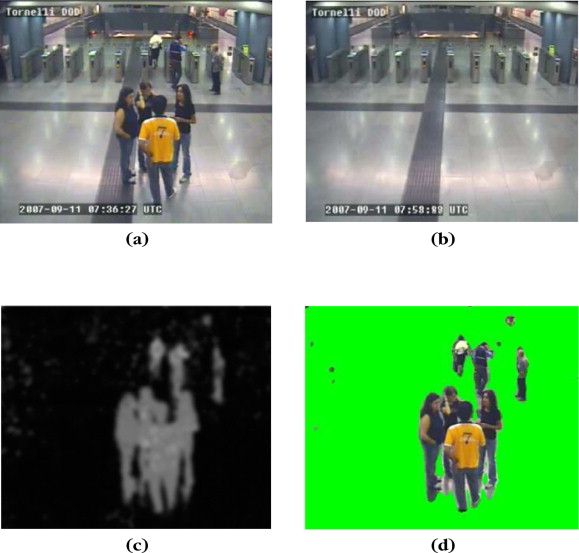

In [9]:
import cv2
alpha = 0.999
threshold = 30

cap = cv2.VideoCapture(0)
# Check if the webcam is opened correctly
if not cap.isOpened():
    raise IOError("Cannot open webcam")
    
ret, frame = cap.read()
zero_frame = cur_frame = mhi_frame = cv2.resize(frame, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
rows, cols, cha = cur_frame.shape

sub_frame = None
g1_frame = None
front1_frame = None
back = cv2.imread("select_background.png")


while True:
    ret, frame = cap.read()

    cur_frame = cv2.resize(frame, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
    cv2.imshow('01_origin', cur_frame)
    
    mhi_frame = cv2.addWeighted(mhi_frame, alpha, cur_frame, 1-alpha, 0)
    cv2.imshow('02_Adaptive Background Image', mhi_frame)
    
    sub_frame = abs(cur_frame - mhi_frame)
    cv2.imshow('03-1_Subtraction', sub_frame)
   
    g1_frame = cv2.cvtColor(sub_frame, cv2.COLOR_BGR2GRAY)
    ret, front1_frame = cv2.threshold(g1_frame, threshold, 255, cv2.THRESH_BINARY)
    
    # optimization: erosion & dilation
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (4,4))
    front1_frame = cv2.morphologyEx(front1_frame, cv2.MORPH_OPEN, kernel)
    front1_frame = cv2.morphologyEx(front1_frame, cv2.MORPH_CLOSE, kernel)
    
    cv2.imshow('03-2_Foreground Threshold', front1_frame)

    result = cv2.resize(back, (cols, rows), interpolation=cv2.INTER_AREA)
    front2_frame = cv2.cvtColor(front1_frame, cv2.COLOR_GRAY2BGR)
    white = cv2.findNonZero(front1_frame)
    if white is not None:
        pts = white.reshape(-1, 2)
        front2_frame[pts[:,1], pts[:,0]] = cur_frame[pts[:,1], pts[:,0]]
        result[pts[:,1], pts[:,0]] = cur_frame[pts[:,1], pts[:,0]]

    cv2.imshow('04_Foreground Detection', front2_frame)
    cv2.imshow('05_Replace B', result)
    c = cv2.waitKey(1)
    if c == 27:
        break


cap.release()
cv2.destroyAllWindows()

QObject::moveToThread: Current thread (0x27ec100) is not the object's thread (0x383ac30).
Cannot move to target thread (0x27ec100)

QObject::moveToThread: Current thread (0x27ec100) is not the object's thread (0x383ac30).
Cannot move to target thread (0x27ec100)

QObject::moveToThread: Current thread (0x27ec100) is not the object's thread (0x383ac30).
Cannot move to target thread (0x27ec100)

QObject::moveToThread: Current thread (0x27ec100) is not the object's thread (0x383ac30).
Cannot move to target thread (0x27ec100)

QObject::moveToThread: Current thread (0x27ec100) is not the object's thread (0x383ac30).
Cannot move to target thread (0x27ec100)

QObject::moveToThread: Current thread (0x27ec100) is not the object's thread (0x383ac30).
Cannot move to target thread (0x27ec100)

QObject::moveToThread: Current thread (0x27ec100) is not the object's thread (0x383ac30).
Cannot move to target thread (0x27ec100)

QObject::moveToThread: Current thread (0x27ec100) is not the object's thread

Ver 0.1
foreground detection 是用「自適應背景減法 + threshold」來分離前景，
但如果 alpha 設很高（0.99），背景更新很慢，容易殘留雜訊或 ghost（殘影），尤其是光線變化或物體移動慢時。
* alpha 太高：背景更新太慢，容易殘留舊影像。
* alpha 太低：背景更新太快，前景容易被吃掉。

Ver 0.2
* AI建議：alpha 可試 0.95 ~ 0.98，threshold 可根據畫面亮度動態調整。
    * 目前測試教室alpha 0.95最適合
* 優化：
    * 用 OpenCV 的 cv2.morphologyEx、cv2.MORPH_OPEN、cv2.MORPH_CLOSE 來去除小雜訊、填補洞。

Ver 1.0
* 優化部份或許可以用高斯平滑化處理(未完成)
* 詢問教授建議：
    * 基本處理大致正確
    * 但想要優話Adaptive Background Subtraction結果，需要從Adaptive Background Image下手
        * 因前景更新太快（很快變成背景），因此導致了較差的效果
        * 須調整alpha（0.99可能也不夠）
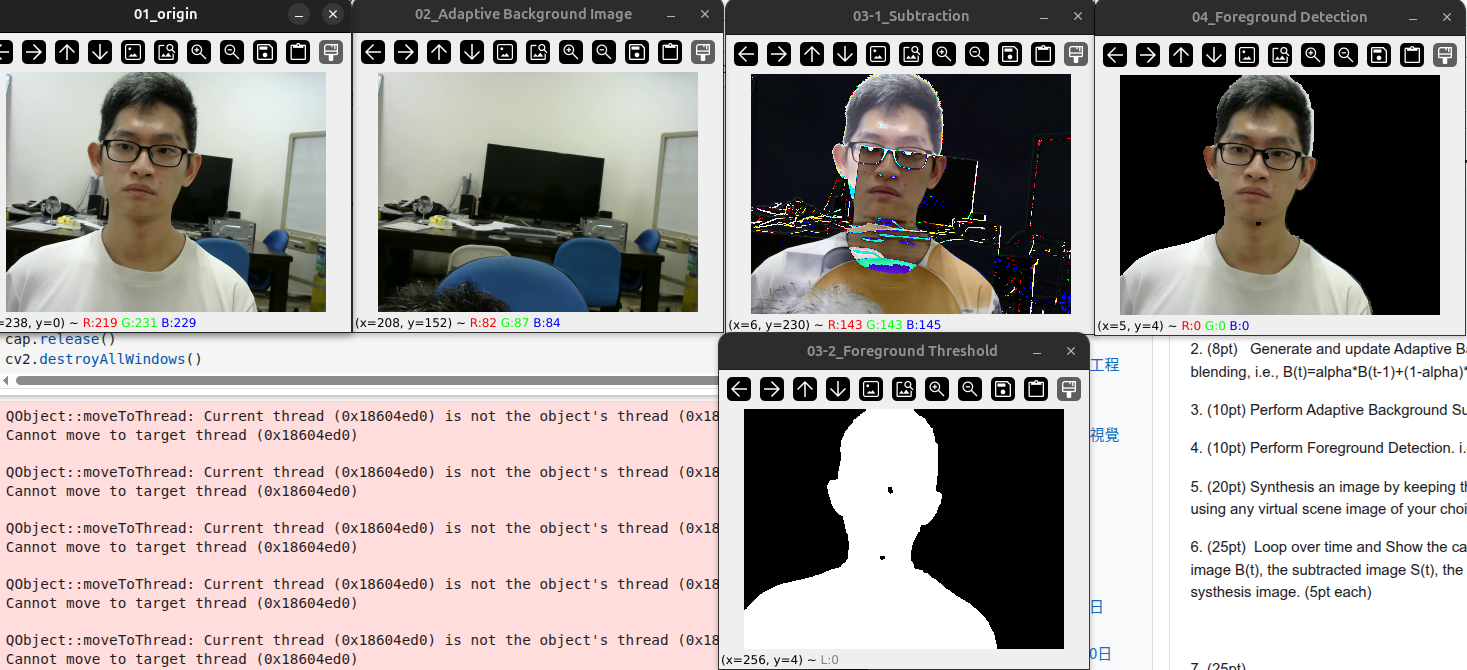

Ver 1.1
* 加入替換背景
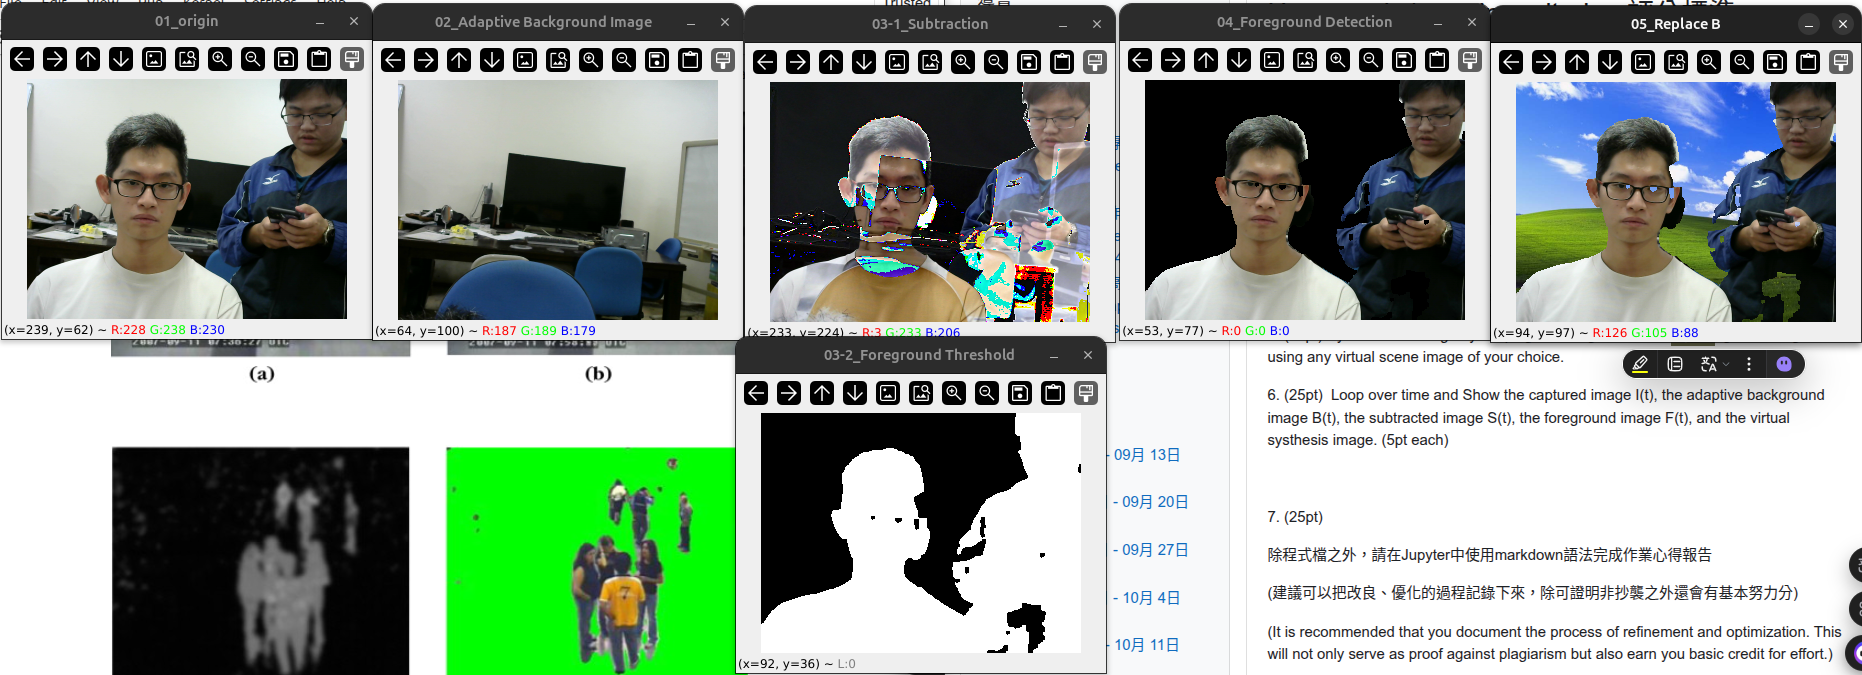